In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from utils import data, style

In [4]:
"""Sequences per week by SIMD quintile, Scotland 2020-2023.

Two stacked panels share an x-axis:
    (A) Weekly sequenced case counts, stratified by SIMD quintile of the
        patient's data zone (1 = most deprived, 5 = least).
    (B) Proportion of positive tests sequenced in that week
        (`wn_prop_sequenced`), which is the critical surveillance-intensity
        covariate used in every downstream model.

VOC epochs are shaded across both panels so readers can orient immediately.
"""

def _weekly_counts_by_simd(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate sequence counts per ISO week × SIMD quintile."""
    df = df.copy()
    df["week"] = df["collection_date"].dt.to_period("W-SUN").dt.start_time
    counts = (
        df.dropna(subset=["dz_simd_quintile"])
        .groupby(["week", "dz_simd_quintile"], observed=True)
        .size()
        .rename("n")
        .reset_index()
    )
    return counts


def _epoch_spans():
    return [
        (lbl, pd.Timestamp(s), pd.Timestamp(e))
        for lbl, s, e in data.VOC_EPOCHS
    ]


def _shade_epochs(ax):
    colors = ["#ffffff", "#f5e6e6", "#e6efdd", "#e6e6f5", "#f5efe0"]
    for (lbl, s, e), c in zip(_epoch_spans(), colors):
        ax.axvspan(s, e, color=c, alpha=0.55, zorder=0)


def _epoch_labels(ax):
    y = ax.get_ylim()[1]
    for lbl, s, e in _epoch_spans():
        ax.text(
            s + (e - s) / 2, y * 0.985, lbl,
            ha="center", va="top", fontsize=6.5, color="#555555",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=0.8),
        )


def make_figure1(df_seq: pd.DataFrame, df_prop: pd.DataFrame) -> plt.Figure:
    fig, (ax_a, ax_b) = style.new_figure(
        width="double", height_in=4.4, nrows=2, ncols=1, sharex=True,
        constrained_layout=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    # Panel A: stacked lines per SIMD quintile
    pivot = (
        df_seq.pivot_table(
            index="week", columns="dz_simd_quintile", values="n", aggfunc="sum"
        ).fillna(0).sort_index()
    )
    pivot = pivot.reindex(columns=[1, 2, 3, 4, 5])

    _shade_epochs(ax_a)
    for q in [1, 2, 3, 4, 5]:
        if q not in pivot.columns:
            continue
        ax_a.plot(
            pivot.index, pivot[q].values,
            color=style.SIMD_QUINTILE_PALETTE[q],
            lw=1.2, label=f"Q{q}" + (" (most deprived)" if q == 1 else (" (least)" if q == 5 else "")),
        )
    ax_a.set_ylim(0, max(0.3, df_seq["n"].max() * 1.1))
    ax_a.set_ylabel("Sequenced cases per week")
    ax_a.legend(
        title="SIMD quintile", loc="upper center", ncol=5, columnspacing=0.8,
        handlelength=1.2, bbox_to_anchor=(0.5, 1.2), frameon=False,
    )
    _epoch_labels(ax_a)

    # Panel B: wn_prop_sequenced over time
    _shade_epochs(ax_b)
    ax_b.plot(
        df_prop["wn_mid_date"], df_prop["wn_prop_sequenced"],
        color="#333333", lw=0.9,
    )
    ax_b.fill_between(
        df_prop["wn_mid_date"], 0, df_prop["wn_prop_sequenced"],
        color="#999999", alpha=0.25,
    )
    ax_b.set_ylim(0, max(0.3, df_prop["wn_prop_sequenced"].max() * 1.05))
    ax_b.set_ylabel("Prop. sequenced")
    ax_b.set_xlabel("")

    for ax in (ax_a, ax_b):
        ax.margins(x=0.005)

    style.add_panel_labels([ax_a, ax_b], y=1.15)
    return fig


def sequences_by_simd_over_time():
    style.set_theme()
    paths = data.Paths.from_config()
    out_dir = paths.root / "analysis/figures"

    # Sequence-level slice (deduplicated on sequence_id to avoid window-overlap double count).
    seq = data.load_analysis_columns(
        ["sequence_id", "collection_date", "dz_simd_quintile"],
        resolution=data.PRIMARY_RESOLUTION, qc=None
    ).drop_duplicates("sequence_id")

    # Window-level prop sequenced (one value per window).
    wn = data.load_analysis_columns(
        ["window_id", "wn_mid_date", "wn_prop_sequenced"],
        resolution=data.PRIMARY_RESOLUTION, qc=None
    ).drop_duplicates("window_id").sort_values("wn_mid_date")


    weekly = _weekly_counts_by_simd(seq)
    fig = make_figure1(weekly, wn)
    _ = style.save_figure(
        fig, out_dir / "sequences_by_simd_over_time",
        width="double", save_png=True, save_pdf=True
    )
    plt.show()
    plt.close(fig)

In [5]:
sequences_by_simd_over_time()

In [2]:
cluster_data = data.load_cluster_features()

In [8]:
cluster_data.columns

Index(['window_id', 'cluster_id', 'n_sequences', 'window_idx', 'wn_mid_date',
       'wn_prop_sequenced', 'who_voc', 'pango_lineage', 'qc_frac_mediocre',
       'qc_frac_bad', 'simd_quintile_mode', 'simd_quintile_std',
       'simd_decile_mode', 'simd_decile_std', 'median_age', 'age_diversity',
       'frac_female', 'frac_vaccinated', 'mean_vacc_dose', 'simd_overall_mean',
       'simd_income_mean', 'simd_employment_mean', 'simd_education_mean',
       'simd_health_mean', 'simd_access_mean', 'simd_crime_mean',
       'simd_housing_mean', 'is_singleton', 'epoch', 'log_seq_prop', 'simd_q'],
      dtype='object')

In [3]:
# Quick check
shifted = cluster_data['n_sequences'] - 1

prop_zeros = (shifted == 0).mean()
mean_s     = shifted.mean()
var_s      = shifted.var()

print(f"Prop zeros:       {prop_zeros:.2%}")
print(f"Overdispersion:   {var_s/mean_s:.2f}x")

Prop zeros:       56.57%
Overdispersion:   234.35x


Fitted mu:    3.059
Fitted alpha: 0.180

Observed zeros:  109268  (56.6%)
Expected zeros:  114732.3  (59.4%)
Excess zeros:    -5464.3

Zero inflation genuine: False


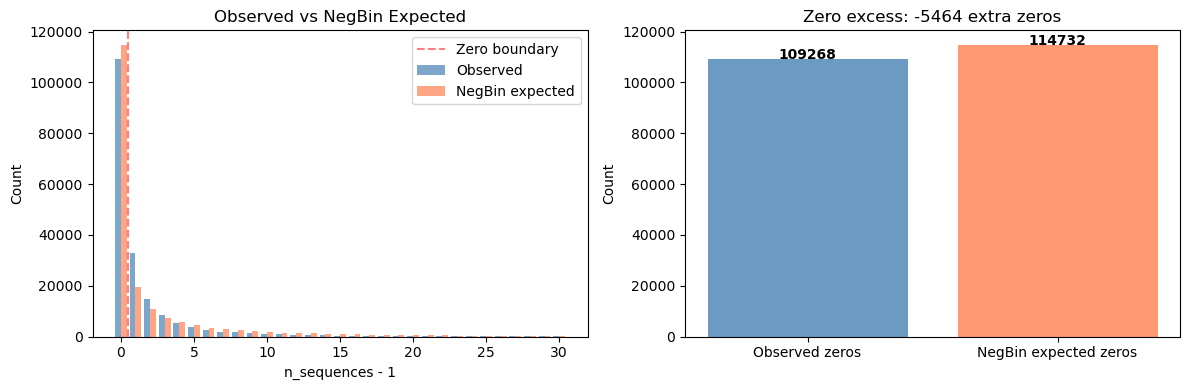

In [7]:
from scipy.stats import nbinom
from scipy.optimize import minimize

y = (cluster_data['n_sequences'] - 1).values  # shifted, ≥ 0

# --- Fit NegBin to ALL data via MLE ---
def negbin_nll(params, data):
    mu, alpha = params
    if mu <= 0 or alpha <= 0:
        return np.inf
    # NegBin parameterised as (r, p) where r=alpha, p=alpha/(alpha+mu)
    r = alpha
    p = alpha / (alpha + mu)
    return -nbinom.logpmf(data, r, p).sum()

result = minimize(
    negbin_nll,
    x0=[y.mean(), 1.0],          # starting guess: mean, dispersion
    args=(y,),
    method='Nelder-Mead'
)
mu_fit, alpha_fit = result.x
print(f"Fitted mu:    {mu_fit:.3f}")
print(f"Fitted alpha: {alpha_fit:.3f}")

# --- Expected vs observed zeros ---
r = alpha_fit
p = alpha_fit / (alpha_fit + mu_fit)

p_zero_negbin   = nbinom.pmf(0, r, p)          # P(Y=0) under fitted NegBin
expected_zeros  = p_zero_negbin * len(y)
observed_zeros  = (y == 0).sum()

print(f"\nObserved zeros:  {observed_zeros}  ({observed_zeros/len(y):.1%})")
print(f"Expected zeros:  {expected_zeros:.1f}  ({p_zero_negbin:.1%})")
print(f"Excess zeros:    {observed_zeros - expected_zeros:.1f}")
print(f"\nZero inflation genuine: {observed_zeros > expected_zeros * 1.1}")

# --- Visual check ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: observed vs NegBin expected counts
max_val = min(y.max(), 30)
obs_counts    = np.array([(y == k).sum() for k in range(max_val + 1)])
exp_counts    = np.array([nbinom.pmf(k, r, p) * len(y) for k in range(max_val + 1)])

x = np.arange(max_val + 1)
axes[0].bar(x - 0.2, obs_counts, width=0.4, label='Observed', alpha=0.7, color='steelblue')
axes[0].bar(x + 0.2, exp_counts, width=0.4, label='NegBin expected', alpha=0.7, color='coral')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Zero boundary')
axes[0].set_xlabel('n_sequences - 1')
axes[0].set_ylabel('Count')
axes[0].set_title('Observed vs NegBin Expected')
axes[0].legend()

# Right: zoom on zero bar only
categories = ['Observed zeros', 'NegBin expected zeros']
values     = [observed_zeros, expected_zeros]
colors     = ['steelblue', 'coral']
axes[1].bar(categories, values, color=colors, alpha=0.8)
axes[1].set_ylabel('Count')
axes[1].set_title(f'Zero excess: {observed_zeros - expected_zeros:.0f} extra zeros')
for i, v in enumerate(values):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

The above diagnostics suggest that while there is some zero inflation, it's not extreme enough to necessarily require a zero-inflated model. The observed excess zeros are about 10% more than expected under the fitted NegBin, which could be due to random variation or mild zero inflation. Given this, we can proceed with a standard negative binomial model for `n_sequences - 1`, which will be more straightforward to interpret and implement in Bambi.

## Bayesian regression with Bambi

### Interaction & Extended Formulas

#### SIMD × epoch interaction
`n_sequences_shifted ~ simd_quintile_mode * epoch + (1|window_id)`

#### Add covariates
`n_sequences_shifted ~ simd_quintile_mode + epoch + median_age + frac_vaccinated + (1|window_id)`

#### SIMD as numeric (linear gradient) vs categorical (flexible per-quintile)
`n_sequences_shifted ~ C(simd_quintile_mode) + epoch + (1|window_id)`

In [ ]:
import bambi as bmb

cluster_data['n_sequences_shifted'] = cluster_data['n_sequences'] - 1

# log_seq_prop must be a column in cluster_data
model = bmb.Model(
    'n_sequences_shifted ~ simd_quintile_mode + epoch + (1|window_id) + offset(log_seq_prop)',
    data=cluster_data,
    family='negativebinomial',
    link='log',
)

# Inspect auto-generated priors before fitting
model.build()
model.plot_priors()

In [ ]:
# priors = {
#     'simd_quintile_mode': bmb.Prior('Normal', mu=0, sigma=0.5),
#     'Intercept':          bmb.Prior('Normal', mu=0, sigma=1),
#     'alpha':              bmb.Prior('HalfNormal', sigma=1),
# }
#
# model = bmb.Model(
#     'n_sequences_shifted ~ simd_quintile_mode + epoch + (1|window_id) + offset(log_seq_prop)',
#     data=cluster_data,
#     family='negativebinomial',
#     priors=priors,
# )